# Simple linear regression is a linear regression with one independent variable, also called the explanatory variable, and one dependent variable, also called the response variable. 
# formula: y = b0 + b1x1
# The intercept β0 represents the predicted value of the dependent variable Y when the independent variable X is zero.
#  coefficient 𝛽1 how much the target (y) changes when one feature (x) changes.
# RMSE — Root Mean Squared Error - Measures how far off your predictions are from the actual values. Lower RMSE → better model fit.
# R² — Coefficient of Determination - Measures how well the model explains the variability of the target. Ranges between 0 and 1: 1.0 → perfect prediction, 0.0 → model predicts as bad as the mean, < 0 → model is worse than predicting the average

In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('housing.csv')
df.head

<bound method NDFrame.head of     0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00
0     0.02731   0.00   7.070  0  0.4690  6.4210  78...                                             
1     0.02729   0.00   7.070  0  0.4690  7.1850  61...                                             
2     0.03237   0.00   2.180  0  0.4580  6.9980  45...                                             
3     0.06905   0.00   2.180  0  0.4580  7.1470  54...                                             
4     0.02985   0.00   2.180  0  0.4580  6.4300  58...                                             
..                                                 ...                                             
500   0.06263   0.00  11.930  0  0.5730  6.5930  69...                                             
501   0.04527   0.00  11.930  0  0.5730  6.1200  76...                                             
502   0.06076   0.00  11.930  0  0.5730  6.9760  91...                

In [3]:
df.isnull().sum()

0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00    0
dtype: int64

In [15]:
import pandas as pd

# Define the column names
cols = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM",
    "AGE","DIS","RAD","TAX","PTRATIO",
    "B","LSTAT","PRICE"
]

# Read the CSV using any whitespace as a delimiter
df = pd.read_csv("housing.csv", delim_whitespace=True, header=None, names=cols)

# Check if we have exactly 15 columns
print(df.shape)  # should be (505, 15)





(506, 14)


C:\Users\VIJAY\AppData\Local\Temp\ipykernel_10516\1446082633.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("housing.csv", delim_whitespace=True, header=None, names=cols)


In [16]:
# Save a clean CSV
df.to_csv("clean_file.csv", index=False)

In [17]:
df = pd.read_csv('clean_file.csv')
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [18]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [24]:
print(df.isna().any())

CRIM       False
ZN         False
INDUS      False
CHAS       False
NOX        False
RM         False
AGE        False
DIS        False
RAD        False
TAX        False
PTRATIO    False
B          False
LSTAT      False
PRICE      False
dtype: bool


In [25]:
x = df[['RM']]
y = df[['PRICE']]

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [27]:
x_train.shape[0]

404

In [28]:
x_test.shape[0]

102

In [29]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

Intercept: [-36.2463189]
Coefficient: [[9.34830141]]


In [33]:
print(x_test.shape)  # should be (n_samples, n_features)
print(y_test.shape)  # should be (n_samples,) or (n_samples, 1)
print(y_pred.shape)  # should be (n_samples,)


(102, 1)
(102, 1)
(102, 1)


In [35]:
# Predict house prices for the test set
y_pred = model.predict(x_test)

y_actual = y_test.values.flatten()   # converts (102,1) → (102,)
y_pred_flat = y_pred.flatten()       # converts (102,1) → (102,)

# Create DataFrame
predictions = pd.DataFrame({
    'Actual': y_actual,
    'Predicted': y_pred_flat
})
print(predictions.head())

   Actual  Predicted
0    23.6  23.732383
1    32.4  26.929502
2    13.6  19.684568
3    22.8  20.451129
4    16.1  22.619935


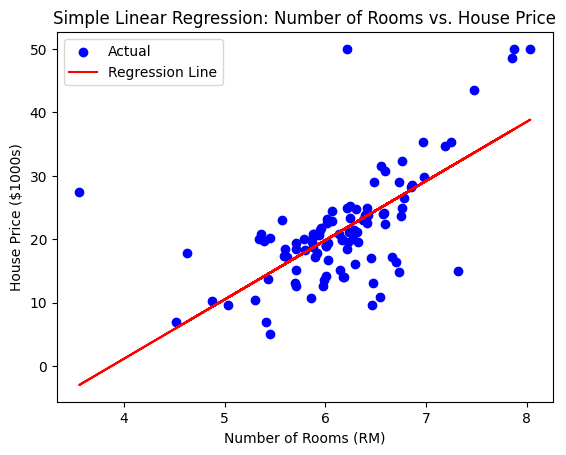

In [37]:
# Plot the actual data points
plt.scatter(x_test, y_test, color='blue', label='Actual')

# Plot the regression line
plt.plot(x_test, y_pred, color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Number of Rooms (RM)')
plt.ylabel('House Price ($1000s)')
plt.title('Simple Linear Regression: Number of Rooms vs. House Price')
plt.legend()
plt.show()

In [38]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2}")

Mean Squared Error: 46.144775347317264
R-squared score: 0.3707569232254778
